# 📊 Nota Estructurada — PPN Basket Tech
## MSFT · AAPL · GOOGL | Capital 100% Protegido | 6 Meses

> **Fecha de análisis:** Abril 2026  
> **Capital protegido:** 100%  
> **Horizonte:** 6 meses  
> **Tasa de referencia:** T-Bill 6M (DTB6)  
> **Estructura:** ZCB + Bull Call Spread sobre Basket Mínima Varianza  
> **Cap de ganancia:** 18%

---

## Estructura del Notebook

| Sección | Descripción |
|---------|-------------|
| **1. Setup** | Dependencias e importaciones |
| **2. Datos** | Precios (yfinance), tasas T-Bill, volatilidades |
| **3. Motor BS** | Funciones Black-Scholes, ZCB, presupuesto |
| **4. Estrategia C** | Parámetros, basket mínima varianza, pricing |
| **5. Payoff & Escenarios** | Gráfica y tabla de payoff por escenario |
| **6. Backtesting** | Simulación histórica de la nota |
| **7. Monte Carlo** | 10,000 trayectorias GBM multivariadas |
| **8. Greeks** | Sensibilidades de las opciones |
| **9. Tasas T-Bill** | Análisis histórico del benchmark |
| **10. Tabla Final** | Ficha completa: parámetros, escenarios, exceso vs benchmark |


---
# 1. Setup e Instalación

In [1]:
import subprocess, sys

required = ['yfinance', 'numpy', 'pandas', 'matplotlib', 'scipy', 'seaborn']
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Todas las dependencias instaladas')

✅ Todas las dependencias instaladas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import minimize, brentq
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#dee2e6',
    'axes.labelcolor':   '#212529',
    'text.color':        '#212529',
    'xtick.color':       '#495057',
    'ytick.color':       '#495057',
    'grid.color':        '#e9ecef',
    'grid.linewidth':     0.8,
    'font.family':       'monospace',
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#dee2e6',
})

COLORS = {
    'MSFT':     '#2DA44E',   # verde
    'AAPL':     '#6E7681',   # gris
    'GOOGL':    '#E16A31',   # naranja
    'basket':   '#0969DA',   # azul
    'capital':  '#CF222E',   # rojo
    'profit':   '#1A7F37',   # verde oscuro
    'neutral':  '#57606A',   # gris oscuro
    'highlight':'#8250DF',   # morado
}

print('✅ Librerías cargadas correctamente')


✅ Librerías cargadas correctamente


---
# 2. Carga de Datos

In [3]:
# ============================================================
# 2.1 TASAS HISTÓRICAS T-BILL (desde archivos locales)
# ============================================================
dtb3_path = 'DTB3.csv'
dtb6_path = 'DTB6.csv'

dtb3 = pd.read_csv(dtb3_path, parse_dates=['observation_date'], index_col='observation_date')
dtb6 = pd.read_csv(dtb6_path, parse_dates=['observation_date'], index_col='observation_date')

RATE_3M = dtb3['DTB3'].dropna().iloc[-1] / 100
RATE_6M = dtb6['DTB6'].dropna().iloc[-1] / 100

print(f'📌 Tasa T-Bill 3M: {RATE_3M*100:.4f}%')
print(f'📌 Tasa T-Bill 6M: {RATE_6M*100:.4f}%  ← benchmark de la estrategia')
print(f'📌 Fecha DTB3: {dtb3.index[-1].date()}')
print(f'📌 Fecha DTB6: {dtb6.index[-1].date()}')

📌 Tasa T-Bill 3M: 3.6200%
📌 Tasa T-Bill 6M: 3.5900%  ← benchmark de la estrategia
📌 Fecha DTB3: 2026-04-20
📌 Fecha DTB6: 2026-04-20


In [4]:
# ============================================================
# 2.2 PRECIOS DE ACCIONES VÍA YFINANCE
# ============================================================
TICKERS    = ['MSFT', 'AAPL', 'GOOGL']
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')
START_DATE = '2022-01-01'
NOTIONAL   = 100_000.0
DIV        = {'MSFT': 0.007, 'AAPL': 0.005, 'GOOGL': 0.0}

print('📥 Descargando precios históricos...')
raw    = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
prices = raw['Close'].dropna()
S0     = {t: float(prices[t].iloc[-1]) for t in TICKERS}

print(f'\n📊 Precios de cierre ({prices.index[-1].date()}):')
for t, p in S0.items():
    print(f'   {t}: ${p:.2f}')

📥 Descargando precios históricos...

📊 Precios de cierre (2026-04-21):
   MSFT: $424.16
   AAPL: $266.17
   GOOGL: $332.29


In [5]:
# ============================================================
# 2.3 VOLATILIDADES Y CORRELACIONES HISTÓRICAS
# ============================================================
returns = prices.pct_change().dropna()
VOL     = {t: float(returns[t].std() * np.sqrt(252)) for t in TICKERS}
CORR    = returns.corr()

print('📈 Volatilidades históricas anualizadas:')
for t, v in VOL.items():
    print(f'   σ({t}) = {v*100:.2f}%')

print('\n🔗 Matriz de correlaciones:')
print(CORR.round(4))

📈 Volatilidades históricas anualizadas:
   σ(MSFT) = 27.24%
   σ(AAPL) = 28.29%
   σ(GOOGL) = 32.28%

🔗 Matriz de correlaciones:
Ticker    AAPL   GOOGL    MSFT
Ticker                        
AAPL    1.0000  0.5723  0.5882
GOOGL   0.5723  1.0000  0.6003
MSFT    0.5882  0.6003  1.0000


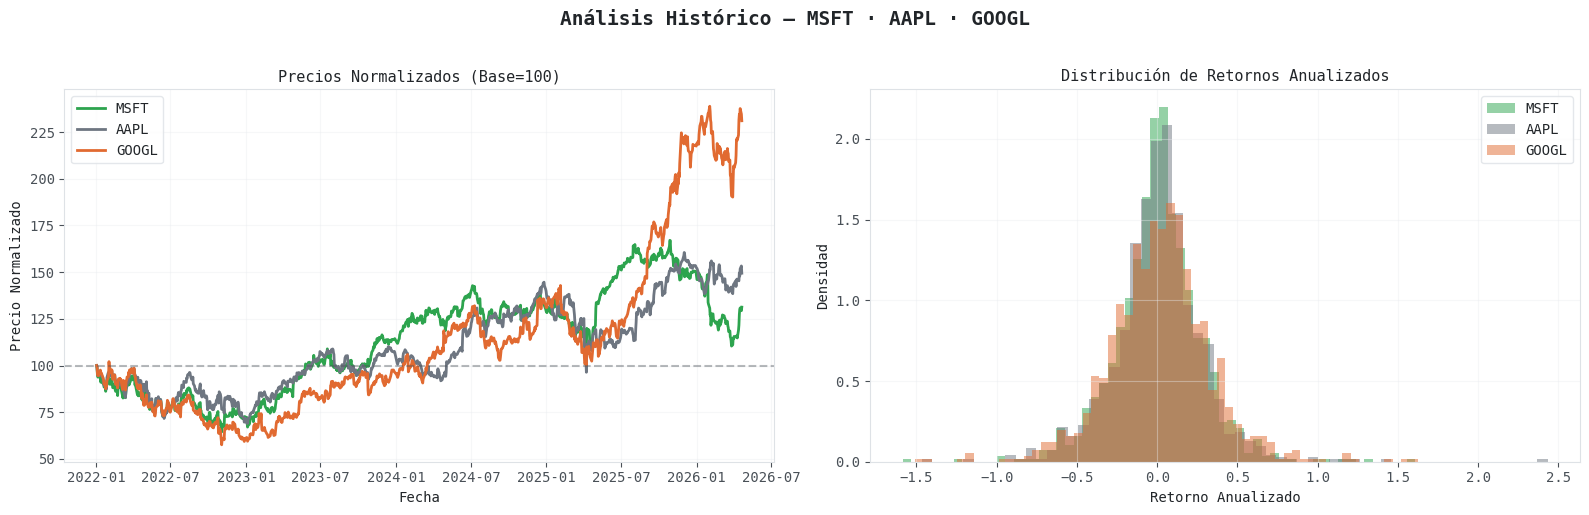

In [6]:
# ============================================================
# 2.4 GRÁFICA HISTÓRICA DE PRECIOS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis Histórico — MSFT · AAPL · GOOGL', fontsize=14,
             fontweight='bold', y=1.02)

ax = axes[0]
norm_prices = prices / prices.iloc[0] * 100
for t in TICKERS:
    ax.plot(norm_prices.index, norm_prices[t], label=t, color=COLORS[t], lw=2)
ax.set_title('Precios Normalizados (Base=100)', fontsize=11)
ax.set_xlabel('Fecha'); ax.set_ylabel('Precio Normalizado')
ax.legend(); ax.grid(True, alpha=0.4)
ax.axhline(100, color='#495057', ls='--', alpha=0.4)

ax2 = axes[1]
for t in TICKERS:
    ax2.hist(returns[t] * np.sqrt(252), bins=60, alpha=0.5,
             label=t, color=COLORS[t], density=True)
ax2.set_title('Distribución de Retornos Anualizados', fontsize=11)
ax2.set_xlabel('Retorno Anualizado'); ax2.set_ylabel('Densidad')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


---
# 3. Motor de Pricing Black-Scholes

In [ ]:
# ============================================================
# BLACK-SCHOLES ENGINE
# ============================================================

def bs_d1d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma, q=0.0):
    if T <= 0: return max(S - K, 0.0)
    d1, d2 = bs_d1d2(S, K, T, r, sigma, q)
    return S * np.exp(-q*T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma, q=0.0):
    if T <= 0: return max(K - S, 0.0)
    d1, d2 = bs_d1d2(S, K, T, r, sigma, q)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q*T) * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, q=0.0, option_type='call'):
    d1, d2 = bs_d1d2(S, K, T, r, sigma, q)
    delta = np.exp(-q*T) * norm.cdf(d1) if option_type == 'call' else -np.exp(-q*T) * norm.cdf(-d1)
    gamma = np.exp(-q*T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T) / 100
    theta_c = (-S*np.exp(-q*T)*norm.pdf(d1)*sigma/(2*np.sqrt(T))
               - r*K*np.exp(-r*T)*norm.cdf(d2)
               + q*S*np.exp(-q*T)*norm.cdf(d1)) / 365
    theta = theta_c if option_type == 'call' else theta_c + r*K*np.exp(-r*T)/365 - q*S*np.exp(-q*T)/365
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta}

def zcb_cost(notional, r, T):
    return notional * np.exp(-r * T)

def option_budget(notional, r, T):
    return notional - zcb_cost(notional, r, T)

print('✅ Motor Black-Scholes cargado')

✅ Motor Black-Scholes cargado
   Verificación call ATM: $7.9059


---
# 4. Estrategia C — PPN Basket Mínima Varianza
## MSFT · AAPL · GOOGL | 6 Meses | Capital 100% Protegido

**Tesis:** El basket de las tres big-tech, ponderado por mínima varianza, captura la recuperación tecnológica en 6 meses minimizando la volatilidad del portafolio.

**Estructura:**
- **ZCB** (Bono Cero Cupón): garantiza el 100% del capital al vencimiento  
- **Bull Call Spread sobre el Basket**: Long Call ATM + Short Call OTM (cap 18%)  
- **Pesos de Mínima Varianza**: optimizados para minimizar σ² del basket

**¿Cómo se construye el basket?**
1. Se calculan los pesos de mínima varianza con la matriz de covarianza histórica (252d)  
2. El basket se normaliza a $1 (precio unitario = 1.0)  
3. El spread se pricía con la **volatilidad implícita del basket** (σ_basket = √(w'Σw))  
4. La **tasa de participación** = Presupuesto de opciones / (Notional × Costo del Spread)  
5. Payoff final = Notional + Notional × Participación × max(min(R_basket, 18%), 0%)


In [8]:
# ============================================================
# ESTRATEGIA C — PARÁMETROS Y PRICING
# ============================================================
T_6M = 6 / 12
r_6m = RATE_6M

# ── Optimización: Mínima Varianza ──────────────────────────
cov_matrix = returns[TICKERS].cov() * 252   # covarianza anualizada

def portfolio_variance(w, cov):
    return w @ cov @ w

n   = len(TICKERS)
w0  = np.ones(n) / n
res = minimize(portfolio_variance, w0, args=(cov_matrix.values,),
               method='SLSQP',
               bounds=[(0.10, 0.70)] * n,
               constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

weights_C   = {t: res.x[i] for i, t in enumerate(TICKERS)}
w_vec       = np.array([weights_C[t] for t in TICKERS])
vol_basket_C = np.sqrt(w_vec @ cov_matrix.values @ w_vec)

# ── Pricing del Spread sobre Basket Normalizado ─────────────
K_atm_C      = 1.0          # strike ATM (basket normalizado)
K_otm_C      = 1.18         # strike OTM = cap del 18%
zcb_C        = zcb_cost(NOTIONAL, r_6m, T_6M)
budget_C     = option_budget(NOTIONAL, r_6m, T_6M)
c_long_C     = bs_call(K_atm_C, K_atm_C, T_6M, r_6m, vol_basket_C)
c_short_C    = bs_call(K_atm_C, K_otm_C, T_6M, r_6m, vol_basket_C)
spread_cost_C = c_long_C - c_short_C
participation_C = budget_C / (NOTIONAL * spread_cost_C)
max_gain_C   = (K_otm_C - K_atm_C) * participation_C    # fracción del notional
bench_6m     = RATE_6M * T_6M                            # T-Bill 6M en el período

# ── Resumen de Parámetros ───────────────────────────────────
print('='*62)
print('  ESTRATEGIA C — PPN Basket Tech | 6 Meses')
print('='*62)
print(f'  {"Capital (Notional):":<32} ${NOTIONAL:>12,.2f}')
print(f'  {"Costo ZCB (6M):":<32} ${zcb_C:>12,.2f}')
print(f'  {"Presupuesto de opciones:":<32} ${budget_C:>12,.2f}')
print(f'  {"Tasa T-Bill 6M (anual):":<32} {RATE_6M*100:>11.4f}%')
print(f'  {"Benchmark período (6M):":<32} {bench_6m*100:>11.4f}%')
print(f'  {"Madurez:":<32} {"6 meses":>12}')
print()
print('  Pesos del Basket (Mínima Varianza):')
for t, w in weights_C.items():
    bar = '█' * int(w * 40)
    print(f'    {t}: {w*100:5.2f}%  {bar}')
print(f'  Volatilidad del Basket (σ_basket): {vol_basket_C*100:.2f}%')
print()
print(f'  {"Long Call ATM (K=1.00):":<32} ${c_long_C:>12.6f}  (por unidad basket)')
print(f'  {"Short Call OTM (K=1.18):":<32} ${c_short_C:>12.6f}')
print(f'  {"Costo neto spread:":<32} ${spread_cost_C:>12.6f}')
print(f'  {"Tasa de Participación:":<32} {participation_C*100:>11.2f}%')
print(f'  {"Cap de ganancia máxima:":<32} {max_gain_C*100:>11.2f}%')
print('='*62)

  ESTRATEGIA C — PPN Basket Tech | 6 Meses
  Capital (Notional):              $  100,000.00
  Costo ZCB (6M):                  $   98,221.01
  Presupuesto de opciones:         $    1,778.99
  Tasa T-Bill 6M (anual):               3.5900%
  Benchmark período (6M):               1.7950%
  Madurez:                              6 meses

  Pesos del Basket (Mínima Varianza):
    MSFT: 46.71%  ██████████████████
    AAPL: 39.11%  ███████████████
    GOOGL: 14.18%  █████
  Volatilidad del Basket (σ_basket): 24.47%

  Long Call ATM (K=1.00):          $    0.077595  (por unidad basket)
  Short Call OTM (K=1.18):         $    0.020338
  Costo neto spread:               $    0.057256
  Tasa de Participación:                 31.07%
  Cap de ganancia máxima:                 5.59%


In [9]:
def _hide_index(s):
    try:
        return s.hide(axis='index')
    except AttributeError:
        return s.hide_index()

TABLE_STYLES = [
    {'selector': 'th',
     'props': [('background-color','#0969da'), ('color','white'),
               ('font-weight','bold'), ('padding','8px 14px'),
               ('border','1px solid #dee2e6'), ('text-align','center')]},
    {'selector': 'td',
     'props': [('padding','6px 12px'), ('border','1px solid #dee2e6'),
               ('font-family','monospace'), ('font-size','13px')]},
    {'selector': 'tr:nth-child(even) td',
     'props': [('background-color','#f8f9fa')]},
    {'selector': 'table',
     'props': [('border-collapse','collapse'), ('width','100%'), ('margin','12px 0')]},
]

def payoff_nota_C(basket_ret):
    spread_pay = max(basket_ret, 0) - max(basket_ret - 0.18, 0)
    return NOTIONAL + NOTIONAL * participation_C * spread_pay

escenarios = {
    'Crash severo  (-30%)': -0.30,
    'Bajista       (-20%)': -0.20,
    'Bajista leve  (-10%)': -0.10,
    'Lateral        (-3%)': -0.03,
    'Lateral         (0%)':  0.00,
    'Lateral        (+3%)':  0.03,
    'Moderado       (+8%)':  0.08,
    'Alcista       (+15%)':  0.15,
    'Cap exacto    (+18%)':  0.18,
    'Fuerte        (+25%)':  0.25,
    'Rally         (+40%)':  0.40,
}

bench_6m = RATE_6M * T_6M

rows = []
for name, ret in escenarios.items():
    val  = payoff_nota_C(ret)
    rend = (val - NOTIONAL) / NOTIONAL
    exc  = rend - bench_6m
    sgn  = '+' if exc >= 0 else ''
    mark = '\u2705' if exc > 0 else ('\u2796' if ret == 0 else '\u274c')
    rows.append({
        'Escenario':      name.strip(),
        'Ret. Basket':    f'{ret*100:+.0f}%',
        'Valor Nota ($)': f'${val:,.2f}',
        'Rendimiento':    f'{rend*100:.2f}%',
        'vs T-Bill':      f'{sgn}{exc*100:.2f}%',
        ' ':              mark,
    })

df_esc = pd.DataFrame(rows)

def _style_row(row):
    mark = row[' ']
    if '\u2705' in mark:
        bg = 'background-color: #d1f8e0; color: #1a7f37'
    elif '\u274c' in mark:
        bg = 'background-color: #ffd7d5; color: #cf222e'
    else:
        bg = 'background-color: #fff8c5; color: #9a6700'
    return [bg] * len(row)

styled = _hide_index(df_esc.style.apply(_style_row, axis=1).set_table_styles(TABLE_STYLES))
display(styled)

print(f'\n  Benchmark T-Bill 6M: {RATE_6M*100:.4f}% anual -> {bench_6m*100:.4f}% en el periodo')
print(f'  Cap maximo de la nota: {max_gain_C*100:.2f}%  |  '
      f'Exceso maximo vs benchmark: {(max_gain_C - bench_6m)*100:.2f}%')


Escenario,Ret. Basket,Valor Nota ($),Rendimiento,vs T-Bill,
Crash severo (-30%),-30%,"$100,000.00",0.00%,-1.80%,❌
Bajista (-20%),-20%,"$100,000.00",0.00%,-1.80%,❌
Bajista leve (-10%),-10%,"$100,000.00",0.00%,-1.80%,❌
Lateral (-3%),-3%,"$100,000.00",0.00%,-1.80%,❌
Lateral (0%),+0%,"$100,000.00",0.00%,-1.80%,➖
Lateral (+3%),+3%,"$100,932.12",0.93%,-0.86%,❌
Moderado (+8%),+8%,"$102,485.65",2.49%,+0.69%,✅
Alcista (+15%),+15%,"$104,660.60",4.66%,+2.87%,✅
Cap exacto (+18%),+18%,"$105,592.71",5.59%,+3.80%,✅
Fuerte (+25%),+25%,"$105,592.71",5.59%,+3.80%,✅



  Benchmark T-Bill 6M: 3.5900% anual -> 1.7950% en el periodo
  Cap maximo de la nota: 5.59%  |  Exceso maximo vs benchmark: 3.80%


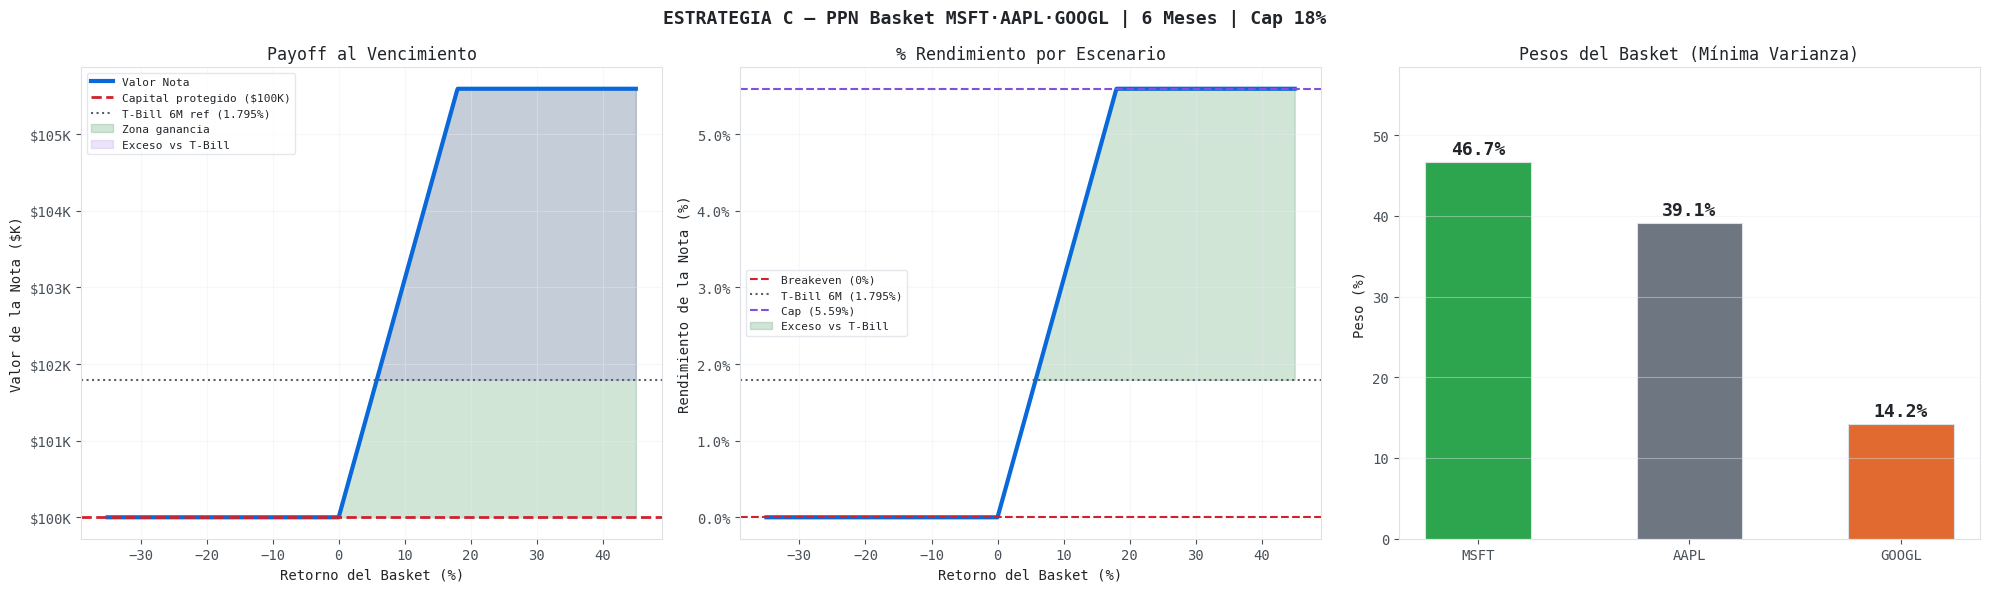

In [10]:
# ============================================================
# GRÁFICAS DE PAYOFF — ESTRATEGIA C
# ============================================================
basket_returns = np.linspace(-0.35, 0.45, 600)
payoffs_C      = np.array([payoff_nota_C(r) for r in basket_returns])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('ESTRATEGIA C — PPN Basket MSFT·AAPL·GOOGL | 6 Meses | Cap 18%',
             fontsize=13, fontweight='bold')

# Panel 1: Payoff de la nota
ax = axes[0]
ax.plot(basket_returns*100, payoffs_C/1000, color=COLORS['basket'], lw=3, label='Valor Nota')
ax.axhline(NOTIONAL/1000, color=COLORS['capital'], ls='--', lw=2, label='Capital protegido ($100K)')
ax.axhline((NOTIONAL*(1 + bench_6m))/1000, color=COLORS['neutral'], ls=':', lw=1.5,
           label=f'T-Bill 6M ref ({bench_6m*100:.3f}%)')
ax.fill_between(basket_returns*100, NOTIONAL/1000, payoffs_C/1000,
                where=payoffs_C > NOTIONAL, alpha=0.20, color=COLORS['profit'], label='Zona ganancia')
ax.fill_between(basket_returns*100, NOTIONAL*(1+bench_6m)/1000, payoffs_C/1000,
                where=payoffs_C > NOTIONAL*(1+bench_6m), alpha=0.15, color=COLORS['highlight'],
                label='Exceso vs T-Bill')
ax.set_xlabel('Retorno del Basket (%)'); ax.set_ylabel('Valor de la Nota ($K)')
ax.set_title('Payoff al Vencimiento')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Panel 2: % Rendimiento de la nota
ax2 = axes[1]
rend_curve = (payoffs_C - NOTIONAL) / NOTIONAL * 100
ax2.plot(basket_returns*100, rend_curve, color=COLORS['basket'], lw=3)
ax2.axhline(0, color=COLORS['capital'], ls='--', lw=1.5, label='Breakeven (0%)')
ax2.axhline(bench_6m*100, color=COLORS['neutral'], ls=':', lw=1.5,
            label=f'T-Bill 6M ({bench_6m*100:.3f}%)')
ax2.axhline(max_gain_C*100, color=COLORS['highlight'], ls='--', lw=1.5,
            label=f'Cap ({max_gain_C*100:.2f}%)')
ax2.fill_between(basket_returns*100, bench_6m*100, rend_curve,
                 where=rend_curve > bench_6m*100, alpha=0.2, color=COLORS['profit'],
                 label='Exceso vs T-Bill')
ax2.set_xlabel('Retorno del Basket (%)'); ax2.set_ylabel('Rendimiento de la Nota (%)')
ax2.set_title('% Rendimiento por Escenario')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.4)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Panel 3: Pesos del basket
ax3 = axes[2]
tl = list(weights_C.keys()); wv = [weights_C[t]*100 for t in tl]
bars = ax3.bar(tl, wv, color=[COLORS[t] for t in tl], width=0.5,
               edgecolor='#dee2e6', linewidth=0.8)
for bar, val in zip(bars, wv):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=13,
             color='#212529', fontweight='bold')
ax3.set_title('Pesos del Basket (Mínima Varianza)')
ax3.set_ylabel('Peso (%)'); ax3.set_ylim(0, max(wv)*1.25)
ax3.grid(True, alpha=0.4, axis='y')

plt.tight_layout(); plt.show()


---
# 5. Backtesting Histórico

Simulamos la nota en diferentes ventanas históricas de 6 meses usando los precios reales de los tres activos y las tasas T-Bill correspondientes.

In [11]:
# ============================================================
# BACKTESTING — ESTRATEGIA C (6 MESES, BASKET)
# ============================================================
dtb6_aligned = dtb6['DTB6'].reindex(prices.index, method='ffill')

bt_results = []
tenor_days  = int(6 * 21)   # ~126 días de trading

for i in range(len(prices) - tenor_days):
    start = prices.index[i]
    end   = prices.index[i + tenor_days]
    rate  = dtb6_aligned.iloc[i] / 100
    T     = 6 / 12

    # Presupuesto real en esa fecha
    zcb_bt     = NOTIONAL * np.exp(-rate * T)
    budget_bt  = NOTIONAL - zcb_bt

    # Retorno del basket ponderado (pesos de mínima varianza actuales)
    basket_ret = sum(weights_C[t] * ((prices[t].iloc[i+tenor_days] / prices[t].iloc[i]) - 1)
                     for t in TICKERS)

    # Participación aproximada con vol_basket_C y tasa del momento
    c_l = bs_call(1.0, 1.0,  T, rate, vol_basket_C)
    c_s = bs_call(1.0, 1.18, T, rate, vol_basket_C)
    sc  = max(c_l - c_s, 1e-8)
    part = budget_bt / (NOTIONAL * sc)

    spread_pay = max(basket_ret, 0) - max(basket_ret - 0.18, 0)
    nota_val   = NOTIONAL + NOTIONAL * part * spread_pay
    nota_ret   = (nota_val - NOTIONAL) / NOTIONAL
    bh_ret     = basket_ret
    bench_ret  = rate * T
    exceso_ret = nota_ret - bench_ret

    bt_results.append({
        'start': start, 'end': end,
        'basket_ret': basket_ret,
        'nota_ret':   nota_ret,
        'bench_ret':  bench_ret,
        'exceso_ret': exceso_ret,
        'nota_val':   nota_val,
        'rate':       rate,
    })

bt = pd.DataFrame(bt_results).set_index('start')

print('✅ Backtesting completado')
print(f'   Períodos analizados: {len(bt)}')
print()
print('='*60)
print('  Estadísticas del Backtesting (Estrategia C)')
print('='*60)
stats = [
    ('Ret. promedio nota (período)',  bt['nota_ret'].mean()*100,  '{:.2f}%'),
    ('Ret. mediana nota',             bt['nota_ret'].median()*100,'{:.2f}%'),
    ('Ret. máximo alcanzado',         bt['nota_ret'].max()*100,   '{:.2f}%'),
    ('Ret. mínimo (=0, protección)',  bt['nota_ret'].min()*100,   '{:.2f}%'),
    ('% períodos con ganancia',       (bt['nota_ret']>0).mean()*100, '{:.1f}%'),
    ('% períodos cap alcanzado',      (bt['nota_ret']>=0.17).mean()*100, '{:.1f}%'),
    ('Exceso vs T-Bill promedio',     bt['exceso_ret'].mean()*100,'{:.2f}%'),
    ('% períodos supera T-Bill',      (bt['exceso_ret']>0).mean()*100, '{:.1f}%'),
    ('Basket ret. promedio',          bt['basket_ret'].mean()*100,'{:.2f}%'),
]
for label, val, fmt in stats:
    print(f'  {label:<38} {fmt.format(val):>8}')
print('='*60)

✅ Backtesting completado
   Períodos analizados: 952

  Estadísticas del Backtesting (Estrategia C)
  Ret. promedio nota (período)              3.58%
  Ret. mediana nota                         4.20%
  Ret. máximo alcanzado                     7.91%
  Ret. mínimo (=0, protección)              0.00%
  % períodos con ganancia                   70.2%
  % períodos cap alcanzado                   0.0%
  Exceso vs T-Bill promedio                 1.53%
  % períodos supera T-Bill                  60.7%
  Basket ret. promedio                      9.25%


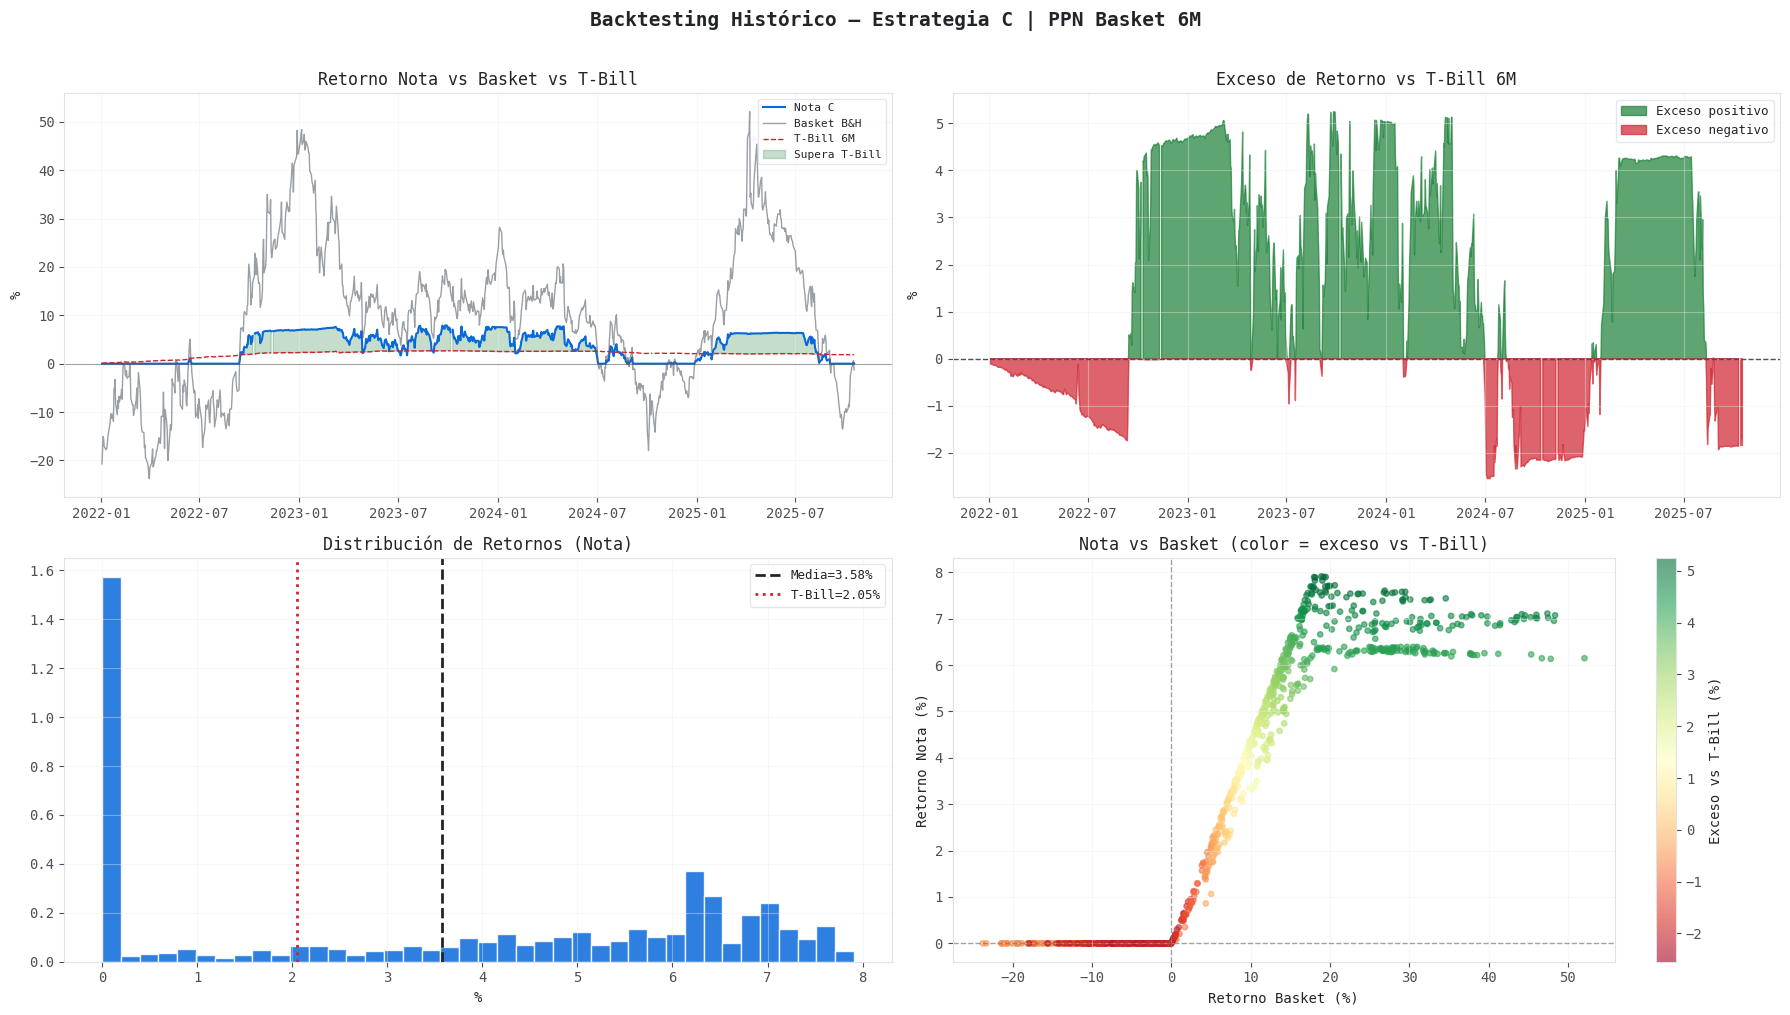

Métrica,Valor
Retorno promedio nota (período),3.58%
Retorno mediana nota,4.20%
Retorno máximo alcanzado,7.91%
"Retorno mínimo (=0, protección)",0.00%
% períodos con ganancia,70.2%
% períodos cap alcanzado,0.0%
Exceso vs T-Bill promedio,1.53%
% períodos supera T-Bill,60.7%
Períodos analizados,952


In [12]:
# ── Gráficas de Backtesting ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Backtesting Histórico — Estrategia C | PPN Basket 6M',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Retorno nota vs basket vs T-Bill
ax = axes[0, 0]
ax.plot(bt.index, bt['nota_ret']*100, color=COLORS['basket'], lw=1.5, label='Nota C')
ax.plot(bt.index, bt['basket_ret']*100, color=COLORS['neutral'], lw=1, alpha=0.6, label='Basket B&H')
ax.plot(bt.index, bt['bench_ret']*100, color=COLORS['capital'], lw=1, ls='--', label='T-Bill 6M')
ax.axhline(0, color='#495057', lw=0.8, alpha=0.5)
ax.fill_between(bt.index, bt['nota_ret']*100, bt['bench_ret']*100,
                where=bt['nota_ret']>bt['bench_ret'], alpha=0.25,
                color=COLORS['profit'], label='Supera T-Bill')
ax.set_title('Retorno Nota vs Basket vs T-Bill'); ax.set_ylabel('%')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

# Panel 2: Exceso de retorno vs benchmark
ax2 = axes[0, 1]
exceso_pos = bt['exceso_ret'].clip(lower=0) * 100
exceso_neg = bt['exceso_ret'].clip(upper=0) * 100
ax2.fill_between(bt.index, exceso_pos, alpha=0.7, color=COLORS['profit'],  label='Exceso positivo')
ax2.fill_between(bt.index, exceso_neg, alpha=0.7, color=COLORS['capital'], label='Exceso negativo')
ax2.axhline(0, color='#495057', ls='--', lw=1)
ax2.set_title('Exceso de Retorno vs T-Bill 6M'); ax2.set_ylabel('%')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Panel 3: Distribución de retornos de la nota
ax3 = axes[1, 0]
ax3.hist(bt['nota_ret']*100, bins=40, color=COLORS['basket'], alpha=0.85,
         edgecolor='white', density=True)
ax3.axvline(bt['nota_ret'].mean()*100, color='#212529', lw=2, ls='--',
            label=f'Media={bt["nota_ret"].mean()*100:.2f}%')
ax3.axvline(bt['bench_ret'].mean()*100, color=COLORS['capital'], lw=2, ls=':',
            label=f'T-Bill={bt["bench_ret"].mean()*100:.2f}%')
ax3.set_title('Distribución de Retornos (Nota)'); ax3.set_xlabel('%')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)

# Panel 4: Scatter nota vs basket
ax4 = axes[1, 1]
sc = ax4.scatter(bt['basket_ret']*100, bt['nota_ret']*100,
                 c=bt['exceso_ret']*100, cmap='RdYlGn', alpha=0.6, s=15)
plt.colorbar(sc, ax=ax4, label='Exceso vs T-Bill (%)')
ax4.axhline(0, color='#495057', ls='--', lw=1, alpha=0.5)
ax4.axvline(0, color='#495057', ls='--', lw=1, alpha=0.5)
ax4.set_xlabel('Retorno Basket (%)'); ax4.set_ylabel('Retorno Nota (%)')
ax4.set_title('Nota vs Basket (color = exceso vs T-Bill)')
ax4.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

# ── Tabla resumen de backtesting ────────────────────────────
bt_stats_rows = [
    {'Métrica': 'Retorno promedio nota (período)', 'Valor': f"{bt['nota_ret'].mean()*100:.2f}%"},
    {'Métrica': 'Retorno mediana nota',             'Valor': f"{bt['nota_ret'].median()*100:.2f}%"},
    {'Métrica': 'Retorno máximo alcanzado',         'Valor': f"{bt['nota_ret'].max()*100:.2f}%"},
    {'Métrica': 'Retorno mínimo (=0, protección)',  'Valor': f"{bt['nota_ret'].min()*100:.2f}%"},
    {'Métrica': '% períodos con ganancia',          'Valor': f"{(bt['nota_ret']>0).mean()*100:.1f}%"},
    {'Métrica': '% períodos cap alcanzado',         'Valor': f"{(bt['nota_ret']>=0.17).mean()*100:.1f}%"},
    {'Métrica': 'Exceso vs T-Bill promedio',        'Valor': f"{bt['exceso_ret'].mean()*100:.2f}%"},
    {'Métrica': '% períodos supera T-Bill',         'Valor': f"{(bt['exceso_ret']>0).mean()*100:.1f}%"},
    {'Métrica': 'Períodos analizados',              'Valor': f"{len(bt):,}"},
]

df_bt = pd.DataFrame(bt_stats_rows)
styled_bt = (
    df_bt.style
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color','#0969da'), ('color','white'),
                   ('font-weight','bold'), ('padding','8px 14px'),
                   ('border','1px solid #dee2e6')]},
        {'selector': 'td',
         'props': [('padding','6px 14px'), ('border','1px solid #dee2e6'),
                   ('font-family','monospace')]},
        {'selector': 'table',
         'props': [('border-collapse','collapse'), ('width','60%'), ('margin','12px 0')]},
        {'selector': 'tr:nth-child(even) td',
         'props': [('background-color','#f8f9fa')]},
    ])
    .set_caption('<b>Resumen Estadístico — Backtesting Histórico (ventanas 6M)</b>')
    
)
styled_bt = _hide_index(styled_bt)
display(styled_bt)


---
# 6. Monte Carlo — Proyección de Escenarios Futuros

10,000 trayectorias GBM multivariadas con correlaciones históricas.

In [13]:
# ============================================================
# MONTE CARLO — SIMULACIÓN GBM MULTIVARIADA (6 MESES)
# ============================================================
np.random.seed(42)
N_SIMS = 10_000
N_DAYS = 126      # ~6 meses
DT     = 1 / 252

mu         = {t: returns[t].mean() * 252 for t in TICKERS}
cov_daily  = returns[TICKERS].cov().values
L          = np.linalg.cholesky(cov_daily)

print(f'🎲 Simulando {N_SIMS:,} trayectorias × {N_DAYS} días...')

S_paths = np.zeros((N_SIMS, N_DAYS + 1, len(TICKERS)))
for i, t in enumerate(TICKERS):
    S_paths[:, 0, i] = S0[t]

for day in range(1, N_DAYS + 1):
    Z      = np.random.standard_normal((N_SIMS, len(TICKERS)))
    corrZ  = Z @ L.T
    for i, t in enumerate(TICKERS):
        drift = (mu[t] - 0.5 * VOL[t]**2) * DT
        shock = VOL[t] * np.sqrt(DT) * corrZ[:, i]
        S_paths[:, day, i] = S_paths[:, day-1, i] * np.exp(drift + shock)

final_rets = {t: (S_paths[:, -1, i] / S0[t]) - 1 for i, t in enumerate(TICKERS)}

# Payoff de la nota para cada simulación
basket_ret_mc = sum(weights_C[t] * final_rets[t] for t in TICKERS)
spread_mc     = np.maximum(basket_ret_mc, 0) - np.maximum(basket_ret_mc - 0.18, 0)
mc_C          = NOTIONAL + NOTIONAL * participation_C * spread_mc
mc_ret        = (mc_C - NOTIONAL) / NOTIONAL
mc_exceso     = mc_ret - bench_6m

print('✅ Simulación completada')
print()
print('='*55)
print('  Estadísticas Monte Carlo — Estrategia C')
print('='*55)
mc_stats = [
    ('Valor esperado',        mc_C.mean(),                   '${:>12,.2f}'),
    ('Percentil  5%',         np.percentile(mc_C, 5),        '${:>12,.2f}'),
    ('Percentil 25%',         np.percentile(mc_C, 25),       '${:>12,.2f}'),
    ('Mediana (P50)',          np.median(mc_C),               '${:>12,.2f}'),
    ('Percentil 75%',         np.percentile(mc_C, 75),       '${:>12,.2f}'),
    ('Percentil 95%',         np.percentile(mc_C, 95),       '${:>12,.2f}'),
    ('Retorno esperado',      mc_ret.mean()*100,             '{:>11.4f}%'),
    ('Exceso vs T-Bill (E)',  mc_exceso.mean()*100,          '{:>11.4f}%'),
    ('P(Ganancia > 0)',        (mc_C>NOTIONAL).mean()*100,   '{:>11.1f}%'),
    ('P(Supera T-Bill)',       (mc_exceso>0).mean()*100,     '{:>11.1f}%'),
    ('P(Cap alcanzado)',       (basket_ret_mc>=0.18).mean()*100, '{:>11.1f}%'),
]
for label, val, fmt in mc_stats:
    print(f'  {label:<28} {fmt.format(val)}')
print('='*55)

🎲 Simulando 10,000 trayectorias × 126 días...
✅ Simulación completada

  Estadísticas Monte Carlo — Estrategia C
  Valor esperado               $  101,505.63
  Percentil  5%                $  101,341.07
  Percentil 25%                $  101,437.99
  Mediana (P50)                $  101,505.79
  Percentil 75%                $  101,573.37
  Percentil 95%                $  101,669.53
  Retorno esperado                  1.5056%
  Exceso vs T-Bill (E)             -0.2894%
  P(Ganancia > 0)                    100.0%
  P(Supera T-Bill)                     0.3%
  P(Cap alcanzado)                     0.0%


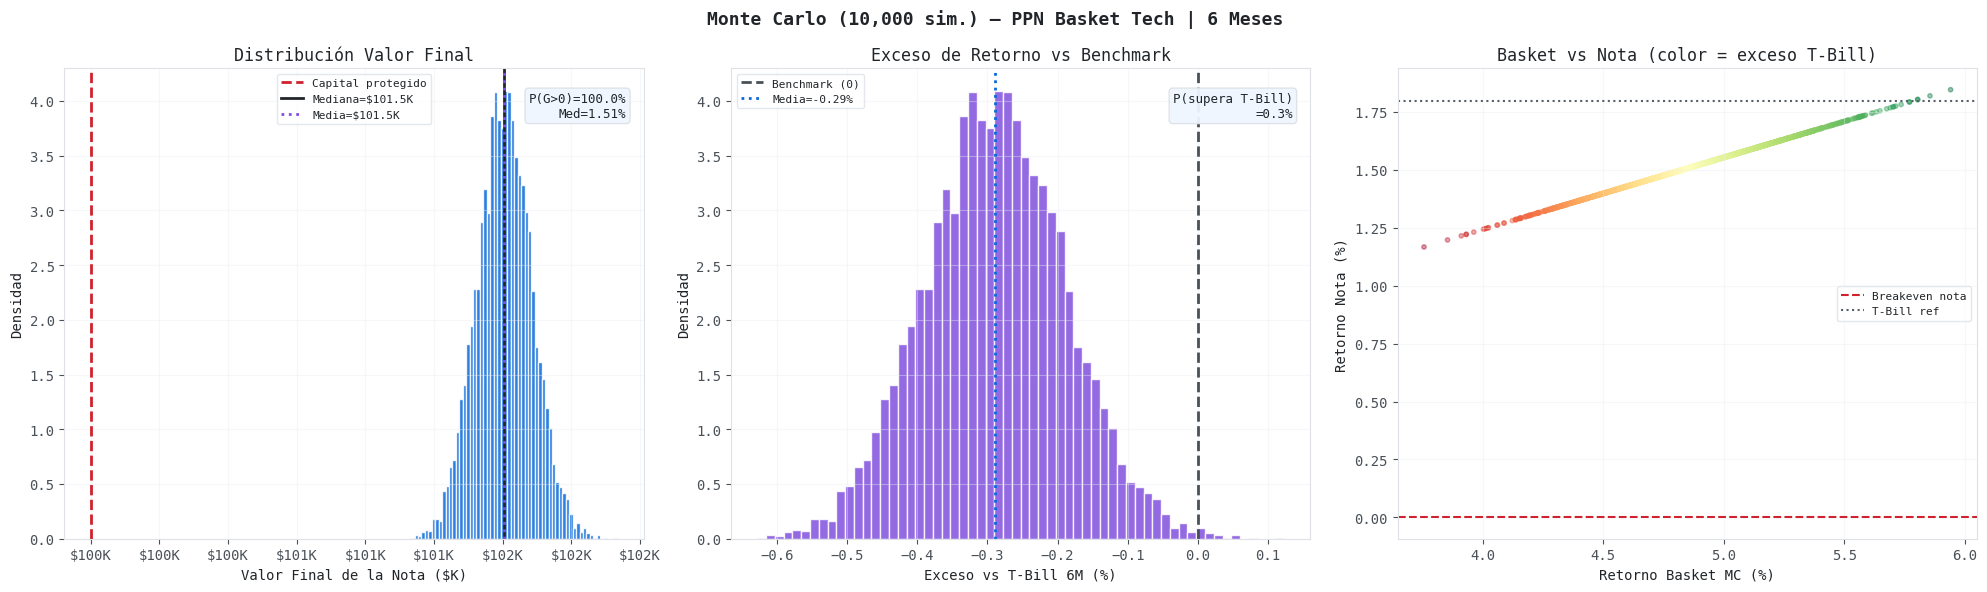

In [14]:
# ── Gráficas Monte Carlo ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Monte Carlo (10,000 sim.) — PPN Basket Tech | 6 Meses',
             fontsize=13, fontweight='bold')

# Panel 1: Distribución del valor final
ax = axes[0]
ax.hist(mc_C/1000, bins=60, density=True, color=COLORS['basket'], alpha=0.85, edgecolor='white')
ax.axvline(NOTIONAL/1000, color=COLORS['capital'], ls='--', lw=2, label='Capital protegido')
ax.axvline(np.median(mc_C)/1000, color='#212529', lw=2, label=f'Mediana=${np.median(mc_C)/1000:.1f}K')
ax.axvline(mc_C.mean()/1000, color=COLORS['highlight'], lw=2, ls=':',
           label=f'Media=${mc_C.mean()/1000:.1f}K')
p_gan = (mc_C > NOTIONAL).mean() * 100
ax.text(0.97, 0.95, f'P(G>0)={p_gan:.1f}%\nMed={np.median(mc_ret)*100:.2f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#f0f6ff', edgecolor='#dee2e6', alpha=0.95))
ax.set_xlabel('Valor Final de la Nota ($K)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución Valor Final')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Panel 2: Distribución del exceso vs T-Bill
ax2 = axes[1]
ax2.hist(mc_exceso*100, bins=60, density=True, color=COLORS['highlight'],
         alpha=0.85, edgecolor='white')
ax2.axvline(0, color='#495057', ls='--', lw=2, label='Benchmark (0)')
ax2.axvline(mc_exceso.mean()*100, color=COLORS['basket'], lw=2, ls=':',
            label=f'Media={mc_exceso.mean()*100:.2f}%')
p_sup = (mc_exceso > 0).mean() * 100
ax2.text(0.97, 0.95, f'P(supera T-Bill)\n={p_sup:.1f}%',
         transform=ax2.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#f0f6ff', edgecolor='#dee2e6', alpha=0.95))
ax2.set_xlabel('Exceso vs T-Bill 6M (%)'); ax2.set_ylabel('Densidad')
ax2.set_title('Exceso de Retorno vs Benchmark')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.4)

# Panel 3: Scatter basket vs nota
ax3 = axes[2]
idx = np.random.choice(N_SIMS, size=2000, replace=False)
ax3.scatter(basket_ret_mc[idx]*100, mc_ret[idx]*100,
            c=mc_exceso[idx]*100, cmap='RdYlGn', alpha=0.4, s=10)
ax3.axhline(0,            color=COLORS['capital'], ls='--', lw=1.5, label='Breakeven nota')
ax3.axhline(bench_6m*100, color=COLORS['neutral'], ls=':',  lw=1.5, label='T-Bill ref')
ax3.set_xlabel('Retorno Basket MC (%)'); ax3.set_ylabel('Retorno Nota (%)')
ax3.set_title('Basket vs Nota (color = exceso T-Bill)')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


---
# 7. Análisis de Greeks

Sensibilidades del Bull Call Spread sobre el basket normalizado.

In [15]:
# ============================================================
# GREEKS — BULL CALL SPREAD SOBRE BASKET (ESTRATEGIA C)
# ============================================================
g_long  = bs_greeks(K_atm_C, K_atm_C, T_6M, r_6m, vol_basket_C, option_type='call')
g_short = bs_greeks(K_atm_C, K_otm_C, T_6M, r_6m, vol_basket_C, option_type='call')

print('='*62)
print('  GREEKS — Bull Call Spread sobre Basket Normalizado')
print('='*62)
print(f'  {"Parámetro":<25} {"Long Call ATM":>14} {"Short Call OTM":>14}')
print('  ' + '-'*54)
print(f'  {"Strike":<25} {K_atm_C:>14.4f} {K_otm_C:>14.4f}')
print(f'  {"Precio (prima)":<25} ${c_long_C:>13.6f} ${c_short_C:>13.6f}')
print()
for greek in ['delta', 'gamma', 'vega', 'theta']:
    vl = g_long[greek]; vs = g_short[greek]
    net = vl - vs
    print(f'  {greek.capitalize():<25} {vl:>14.6f} {vs:>14.6f}')

print()
print('  Greek NETO del Spread:')
for greek in ['delta', 'gamma', 'vega', 'theta']:
    net = g_long[greek] - g_short[greek]
    print(f'  {greek.capitalize():<25} {net:>14.6f}')

# Escalar por participación y notional
print()
print('  Greek NETO × Participación × Notional (en $):')
for greek in ['delta', 'gamma', 'vega', 'theta']:
    net_scaled = (g_long[greek] - g_short[greek]) * participation_C * NOTIONAL
    print(f'  {greek.capitalize():<25} ${net_scaled:>13,.4f}')
print('='*62)

  GREEKS — Bull Call Spread sobre Basket Normalizado
  Parámetro                  Long Call ATM Short Call OTM
  ------------------------------------------------------
  Strike                            1.0000         1.1800
  Precio (prima)            $     0.077595 $     0.020338

  Delta                           0.575445       0.221760
  Gamma                           2.264157       1.718963
  Vega                            0.002770       0.002103
  Theta                          -0.000235      -0.000161

  Greek NETO del Spread:
  Delta                           0.353685
  Gamma                           0.545193
  Vega                            0.000667
  Theta                          -0.000074

  Greek NETO × Participación × Notional (en $):
  Delta                     $  10,989.2069
  Gamma                     $  16,939.5068
  Vega                      $      20.7267
  Theta                     $      -2.2955


---
# 8. Análisis Histórico de Tasas T-Bill

Contexto del benchmark: evolución de la tasa libre de riesgo que determina el presupuesto de opciones.

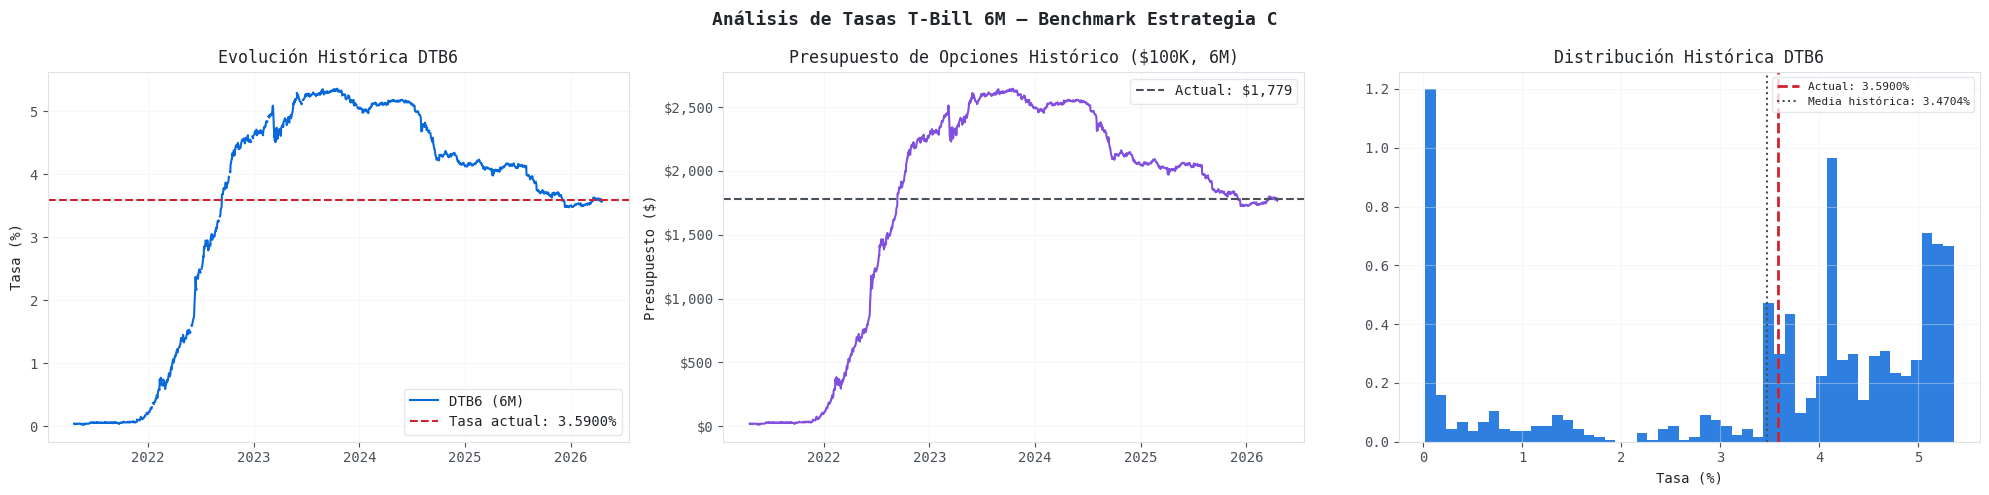


  Estadísticas DTB6 (T-Bill 6M):
  Tasa actual               3.5900%
  Promedio histórico        3.4704%
  Máximo histórico          5.3600%
  Mínimo histórico          0.0200%
  Percentil 25%             2.8350%
  Mediana                   4.1300%
  Percentil 75%             4.9300%


In [16]:
# ============================================================
# ANÁLISIS DE TASAS — DTB6 (Benchmark Estrategia C)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Análisis de Tasas T-Bill 6M — Benchmark Estrategia C',
             fontsize=13, fontweight='bold')

# Panel 1: Evolución histórica DTB6
ax = axes[0]
ax.plot(dtb6.index, dtb6['DTB6'], color=COLORS['basket'], lw=1.5, label='DTB6 (6M)')
ax.axhline(RATE_6M*100, color=COLORS['capital'], ls='--', lw=1.5,
           label=f'Tasa actual: {RATE_6M*100:.4f}%')
ax.set_title('Evolución Histórica DTB6')
ax.set_ylabel('Tasa (%)'); ax.legend(); ax.grid(True, alpha=0.4)

# Panel 2: Presupuesto histórico de opciones ($100K notional)
ax2 = axes[1]
budget_hist = NOTIONAL * (1 - np.exp(-dtb6['DTB6'].dropna() / 100 * T_6M))
ax2.plot(budget_hist.index, budget_hist, color=COLORS['highlight'], lw=1.5)
ax2.axhline(budget_C, color='#495057', ls='--', lw=1.5, label=f'Actual: ${budget_C:,.0f}')
ax2.set_title('Presupuesto de Opciones Histórico ($100K, 6M)')
ax2.set_ylabel('Presupuesto ($)'); ax2.legend(); ax2.grid(True, alpha=0.4)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel 3: Distribución de tasas DTB6
ax3 = axes[2]
ax3.hist(dtb6['DTB6'].dropna(), bins=50, color=COLORS['basket'], alpha=0.85, density=True)
ax3.axvline(RATE_6M*100, color=COLORS['capital'], ls='--', lw=2,
            label=f'Actual: {RATE_6M*100:.4f}%')
ax3.axvline(dtb6['DTB6'].mean(), color='#495057', ls=':', lw=1.5,
            label=f'Media histórica: {dtb6["DTB6"].mean():.4f}%')
ax3.set_title('Distribución Histórica DTB6')
ax3.set_xlabel('Tasa (%)'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print(f'\n  Estadísticas DTB6 (T-Bill 6M):')
for label, val in [
    ('Tasa actual',          RATE_6M*100),
    ('Promedio histórico',   dtb6['DTB6'].mean()),
    ('Máximo histórico',     dtb6['DTB6'].max()),
    ('Mínimo histórico',     dtb6['DTB6'].min()),
    ('Percentil 25%',        dtb6['DTB6'].quantile(0.25)),
    ('Mediana',              dtb6['DTB6'].median()),
    ('Percentil 75%',        dtb6['DTB6'].quantile(0.75)),
]:
    print(f'  {label:<25} {val:.4f}%')


---
# 9. Ficha Completa — Tabla Final de la Estrategia

In [17]:
# ============================================================
# TABLA FINAL COMPRENSIVA — ESTRATEGIA C
# ============================================================

def _tabla_html(title, rows, header_color='#0969da'):
    """Construye un bloque HTML de tabla con sección titulada."""
    header_bg = header_color
    html  = f'<h4 style="margin:18px 0 6px;color:#212529;font-family:monospace">{title}</h4>'
    html += '<table style="border-collapse:collapse;width:100%;font-family:monospace;font-size:13px">'
    for label, val in rows:
        html += (
            f'<tr>'
            f'<td style="padding:5px 14px;border:1px solid #dee2e6;background:#f8f9fa;'
            f'font-weight:bold;width:45%">{label}</td>'
            f'<td style="padding:5px 14px;border:1px solid #dee2e6">{val}</td>'
            f'</tr>'
        )
    html += '</table>'
    return html

parts = []

# ── Estructura ──────────────────────────────────────────────
parts.append(_tabla_html('Estructura de la Nota', [
    ('Tipo de Nota',               'PPN (Principal Protected Note)'),
    ('Subyacente',                 'Basket MSFT · AAPL · GOOGL'),
    ('Metodología de pesos',       'Mínima Varianza (Markowitz)'),
    ('Horizonte',                  '6 meses'),
    ('Capital Protegido',          '100% garantizado'),
    ('Notional',                   f'${NOTIONAL:,.2f}'),
]))

# ── Composición del basket ──────────────────────────────────
basket_rows = [(f'Peso {t}', f'{weights_C[t]*100:.2f}%') for t in TICKERS]
basket_rows.append(('Volatilidad del Basket (σ)', f'{vol_basket_C*100:.4f}%'))
parts.append(_tabla_html('Composición del Basket', basket_rows))

# ── Tasas y presupuesto ─────────────────────────────────────
parts.append(_tabla_html('Tasas y Presupuesto', [
    ('Tasa T-Bill 6M (anual)',      f'{RATE_6M*100:.4f}%'),
    ('Benchmark período (6 meses)', f'{bench_6m*100:.4f}%'),
    ('Costo ZCB',                   f'${zcb_C:,.2f}'),
    ('Presupuesto de opciones',     f'${budget_C:,.2f}'),
    ('Pct presupuesto / Notional',  f'{budget_C/NOTIONAL*100:.4f}%'),
]))

# ── Pricing del spread ──────────────────────────────────────
parts.append(_tabla_html('Pricing del Bull Call Spread', [
    ('Long Call ATM (K=1.00)',      f'${c_long_C:.6f} por unidad basket'),
    ('Short Call OTM (K=1.18)',     f'${c_short_C:.6f} por unidad basket'),
    ('Costo neto spread',           f'${spread_cost_C:.6f} por unidad basket'),
    ('Tasa de Participación',       f'{participation_C*100:.4f}%'),
    ('Cap de ganancia (basket+18%)', f'{max_gain_C*100:.4f}%'),
    ('Ganancia máxima en $',        f'${NOTIONAL * max_gain_C:,.2f}'),
]))

# ── Monte Carlo ─────────────────────────────────────────────
parts.append(_tabla_html('Análisis Monte Carlo (10,000 sim. GBM)', [
    ('Valor Esperado',          f'${mc_C.mean():,.2f}'),
    ('Retorno Esperado',        f'{mc_ret.mean()*100:.4f}%'),
    ('Exceso Esperado vs T-Bill', f'{mc_exceso.mean()*100:.4f}%'),
    ('Mediana (P50)',           f'${np.median(mc_C):,.2f}'),
    ('Percentil  5%',           f'${np.percentile(mc_C,5):,.2f}'),
    ('Percentil 95%',           f'${np.percentile(mc_C,95):,.2f}'),
    ('P(Ganancia > 0)',         f'{(mc_C>NOTIONAL).mean()*100:.1f}%'),
    ('P(Supera T-Bill 6M)',     f'{(mc_exceso>0).mean()*100:.1f}%'),
    ('P(Cap 18% alcanzado)',    f'{(basket_ret_mc>=0.18).mean()*100:.1f}%'),
]))

# ── Backtesting ─────────────────────────────────────────────
parts.append(_tabla_html('Backtesting Histórico (ventanas 6M)', [
    ('Períodos analizados',         f'{len(bt):,}'),
    ('Retorno promedio nota',       f"{bt['nota_ret'].mean()*100:.2f}%"),
    ('Exceso promedio vs T-Bill',   f"{bt['exceso_ret'].mean()*100:.2f}%"),
    ('% períodos con ganancia',     f"{(bt['nota_ret']>0).mean()*100:.1f}%"),
    ('% períodos supera T-Bill',    f"{(bt['exceso_ret']>0).mean()*100:.1f}%"),
]))

# ── Greeks ──────────────────────────────────────────────────
greek_rows = []
for g in ['delta', 'gamma', 'vega', 'theta']:
    net = g_long[g] - g_short[g]
    scaled = net * participation_C * NOTIONAL
    greek_rows.append((f'{g.capitalize()} neto', f'{net:.6f}  →  ${scaled:,.4f}'))
parts.append(_tabla_html('Greeks del Spread (Basket Normalizado)', greek_rows))

# ── Render ───────────────────────────────────────────────────
header = (
    '<div style="background:#0969da;color:white;padding:12px 18px;'
    'border-radius:6px 6px 0 0;font-family:monospace;font-size:15px;font-weight:bold">'
    '📊 FICHA TÉCNICA — PPN BASKET TECH | ESTRATEGIA C</div>'
)
wrapper_start = '<div style="border:1px solid #dee2e6;border-radius:0 0 6px 6px;padding:16px">'
wrapper_end   = '</div>'

display(HTML(header + wrapper_start + ''.join(parts) + wrapper_end))


Tipo de Nota,PPN (Principal Protected Note)
Subyacente,Basket MSFT · AAPL · GOOGL
Metodología de pesos,Mínima Varianza (Markowitz)
Horizonte,6 meses
Capital Protegido,100% garantizado
Notional,"$100,000.00"
Peso MSFT,46.71%
Peso AAPL,39.11%
Peso GOOGL,14.18%
Volatilidad del Basket (σ),24.4714%
Tasa T-Bill 6M (anual),3.5900%


---
# 10. Datos Reales de Opciones — LSEG

Ingresa los datos de la cadena de opciones obtenidos de LSEG Workspace para cada activo.  
Campos disponibles: **Bid · Ask · Last · OI · OI Chg · ImpVol Mid · Delta Mid · Strike**.

> Rellena la plantilla en la siguiente celda y vuelve a ejecutar para ver el análisis completo.

In [18]:
# ============================================================
# PLANTILLA DE DATOS REALES — LSEG WORKSPACE
# ============================================================
# Columnas: Strike | Bid | Ask | Last | OI | OI_Chg | ImpVol_Mid | Delta_Mid
# ImpVol_Mid en formato decimal (p.ej. 0.28 = 28%)
# OI_Chg puede ser negativo

options_lseg = {

    'MSFT': pd.DataFrame([
        # Strike ATM ≈ $418  |  Strike OTM (+18%) ≈ $493
        {'Strike': 390, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 400, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 410, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 418, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # ATM
        {'Strike': 430, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 450, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 470, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 493, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # OTM cap +18%
    ]),

    'AAPL': pd.DataFrame([
        # Strike ATM ≈ $273  |  Strike OTM (+18%) ≈ $322
        {'Strike': 250, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 260, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 273, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # ATM
        {'Strike': 285, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 300, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 322, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # OTM cap +18%
    ]),

    'GOOGL': pd.DataFrame([
        # Strike ATM ≈ $337  |  Strike OTM (+18%) ≈ $398
        {'Strike': 310, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 325, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 337, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # ATM
        {'Strike': 350, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 375, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},
        {'Strike': 398, 'Bid': 0.00, 'Ask': 0.00, 'Last': 0.00, 'OI':    0, 'OI_Chg': 0, 'ImpVol_Mid': 0.00, 'Delta_Mid': 0.00},  # OTM cap +18%
    ]),
}

print('📋 Plantilla LSEG cargada. Rellena los valores reales y vuelve a ejecutar.')
for t in TICKERS:
    print(f'   {t}: {len(options_lseg[t])} strikes listos para datos')


📋 Plantilla LSEG cargada. Rellena los valores reales y vuelve a ejecutar.
   MSFT: 8 strikes listos para datos
   AAPL: 6 strikes listos para datos
   GOOGL: 6 strikes listos para datos


In [19]:
# ============================================================
# ANÁLISIS OPCIONES LSEG vs BLACK-SCHOLES TEÓRICO
# ============================================================

def _analyze_chain(ticker, df_opts, S, r, T, sigma_hist, q=0.0):
    rows = []
    for _, row in df_opts.iterrows():
        K          = row['Strike']
        moneyness  = K / S
        bs_price   = bs_call(S, K, T, r, sigma_hist, q)
        d1, _      = bs_d1d2(S, K, T, r, sigma_hist, q)
        bs_delta   = float(norm.cdf(d1))
        mid_mkt    = (row['Bid'] + row['Ask']) / 2 if row['Ask'] > 0 else row['Last']
        ba_spread  = (row['Ask'] - row['Bid']) if row['Ask'] > 0 else float('nan')
        dif        = round(mid_mkt - bs_price, 4) if mid_mkt > 0 else float('nan')
        rows.append({
            'Strike ($)':    K,
            'Moneyness':     f'{moneyness:.3f}',
            'Bid':           f'${row["Bid"]:.2f}'    if row['Bid'] > 0  else '—',
            'Ask':           f'${row["Ask"]:.2f}'    if row['Ask'] > 0  else '—',
            'Last':          f'${row["Last"]:.2f}'   if row["Last"] > 0 else '—',
            'B-A Spread':    f'${ba_spread:.2f}'     if not pd.isna(ba_spread) and ba_spread > 0 else '—',
            'Mid Mkt':       f'${mid_mkt:.4f}'       if mid_mkt > 0     else '—',
            'BS Teórico':    f'${bs_price:.4f}',
            'Dif Mkt−BS':    f'${dif:+.4f}'          if not pd.isna(dif) else '—',
            'ImpVol Mkt':    f'{row["ImpVol_Mid"]*100:.2f}%' if row['ImpVol_Mid'] > 0 else '—',
            'σ Hist':        f'{sigma_hist*100:.2f}%',
            'Delta Mkt':     f'{row["Delta_Mid"]:.4f}'  if row['Delta_Mid'] != 0 else '—',
            'Delta BS':      f'{bs_delta:.4f}',
            'OI':            f'{int(row["OI"]):,}'       if row['OI'] > 0   else '—',
            'OI Chg':        f'{int(row["OI_Chg"]):+,}'  if row['OI_Chg'] != 0 else '—',
        })
    return pd.DataFrame(rows)


for ticker in TICKERS:
    df_result = _analyze_chain(
        ticker, options_lseg[ticker],
        S0[ticker], RATE_6M, T_6M, VOL[ticker], DIV[ticker]
    )

    header_color = COLORS[ticker]
    styled = (
        df_result.style
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', header_color), ('color', 'white'),
                       ('font-weight', 'bold'), ('padding', '7px 10px'),
                       ('border', '1px solid #dee2e6'), ('text-align', 'center'),
                       ('white-space', 'nowrap')]},
            {'selector': 'td',
             'props': [('padding', '5px 10px'), ('border', '1px solid #dee2e6'),
                       ('font-family', 'monospace'), ('font-size', '12px'),
                       ('text-align', 'right')]},
            {'selector': 'table',
             'props': [('border-collapse', 'collapse'), ('width', '100%'),
                       ('margin', '10px 0')]},
            {'selector': 'tr:nth-child(even) td',
             'props': [('background-color', '#f8f9fa')]},
        ])
        .set_caption(
            f'<b style="font-size:14px">{ticker} — Cadena de Opciones CALL | '
            f'S₀=${S0[ticker]:.2f} | σ_hist={VOL[ticker]*100:.2f}% | '
            f'Horizonte 6M | Datos: LSEG</b>'
        )
    )
    styled = _hide_index(styled)
    display(styled)
    print()


Strike ($),Moneyness,Bid,Ask,Last,B-A Spread,Mid Mkt,BS Teórico,Dif Mkt−BS,ImpVol Mkt,σ Hist,Delta Mkt,Delta BS,OI,OI Chg
390.000000,0.919,—,—,—,—,—,$54.6542,—,—,27.24%,—,0.7281,—,—
400.000000,0.943,—,—,—,—,—,$48.4054,—,—,27.24%,—,0.6829,—,—
410.000000,0.967,—,—,—,—,—,$42.6445,—,—,27.24%,—,0.6359,—,—
418.000000,0.985,—,—,—,—,—,$38.3884,—,—,27.24%,—,0.5977,—,—
430.000000,1.014,—,—,—,—,—,$32.5852,—,—,27.24%,—,0.5400,—,—
450.000000,1.061,—,—,—,—,—,$24.4022,—,—,27.24%,—,0.4460,—,—
470.000000,1.108,—,—,—,—,—,$17.9276,—,—,27.24%,—,0.3589,—,—
493.000000,1.162,—,—,—,—,—,$12.2999,—,—,27.24%,—,0.2711,—,—


Strike ($),Moneyness,Bid,Ask,Last,B-A Spread,Mid Mkt,BS Teórico,Dif Mkt−BS,ImpVol Mkt,σ Hist,Delta Mkt,Delta BS,OI,OI Chg
250.000000,0.939,—,—,—,—,—,$31.8610,—,—,28.29%,—,0.6881,—,—
260.000000,0.977,—,—,—,—,—,$26.2039,—,—,28.29%,—,0.6158,—,—
273.000000,1.026,—,—,—,—,—,$19.9642,—,—,28.29%,—,0.5202,—,—
285.000000,1.071,—,—,—,—,—,$15.2673,—,—,28.29%,—,0.4347,—,—
300.000000,1.127,—,—,—,—,—,$10.6824,—,—,28.29%,—,0.3369,—,—
322.000000,1.210,—,—,—,—,—,$6.0779,—,—,28.29%,—,0.2193,—,—


Strike ($),Moneyness,Bid,Ask,Last,B-A Spread,Mid Mkt,BS Teórico,Dif Mkt−BS,ImpVol Mkt,σ Hist,Delta Mkt,Delta BS,OI,OI Chg
310.000000,0.933,—,—,—,—,—,$44.9197,—,—,32.28%,—,0.6904,—,—
325.000000,0.978,—,—,—,—,—,$36.5932,—,—,32.28%,—,0.6141,—,—
337.000000,1.014,—,—,—,—,—,$30.7856,—,—,32.28%,—,0.5522,—,—
350.000000,1.053,—,—,—,—,—,$25.3152,—,—,32.28%,—,0.4862,—,—
375.000000,1.129,—,—,—,—,—,$16.9824,—,—,32.28%,—,0.3681,—,—
398.000000,1.198,—,—,—,—,—,$11.4801,—,—,32.28%,—,0.2750,—,—


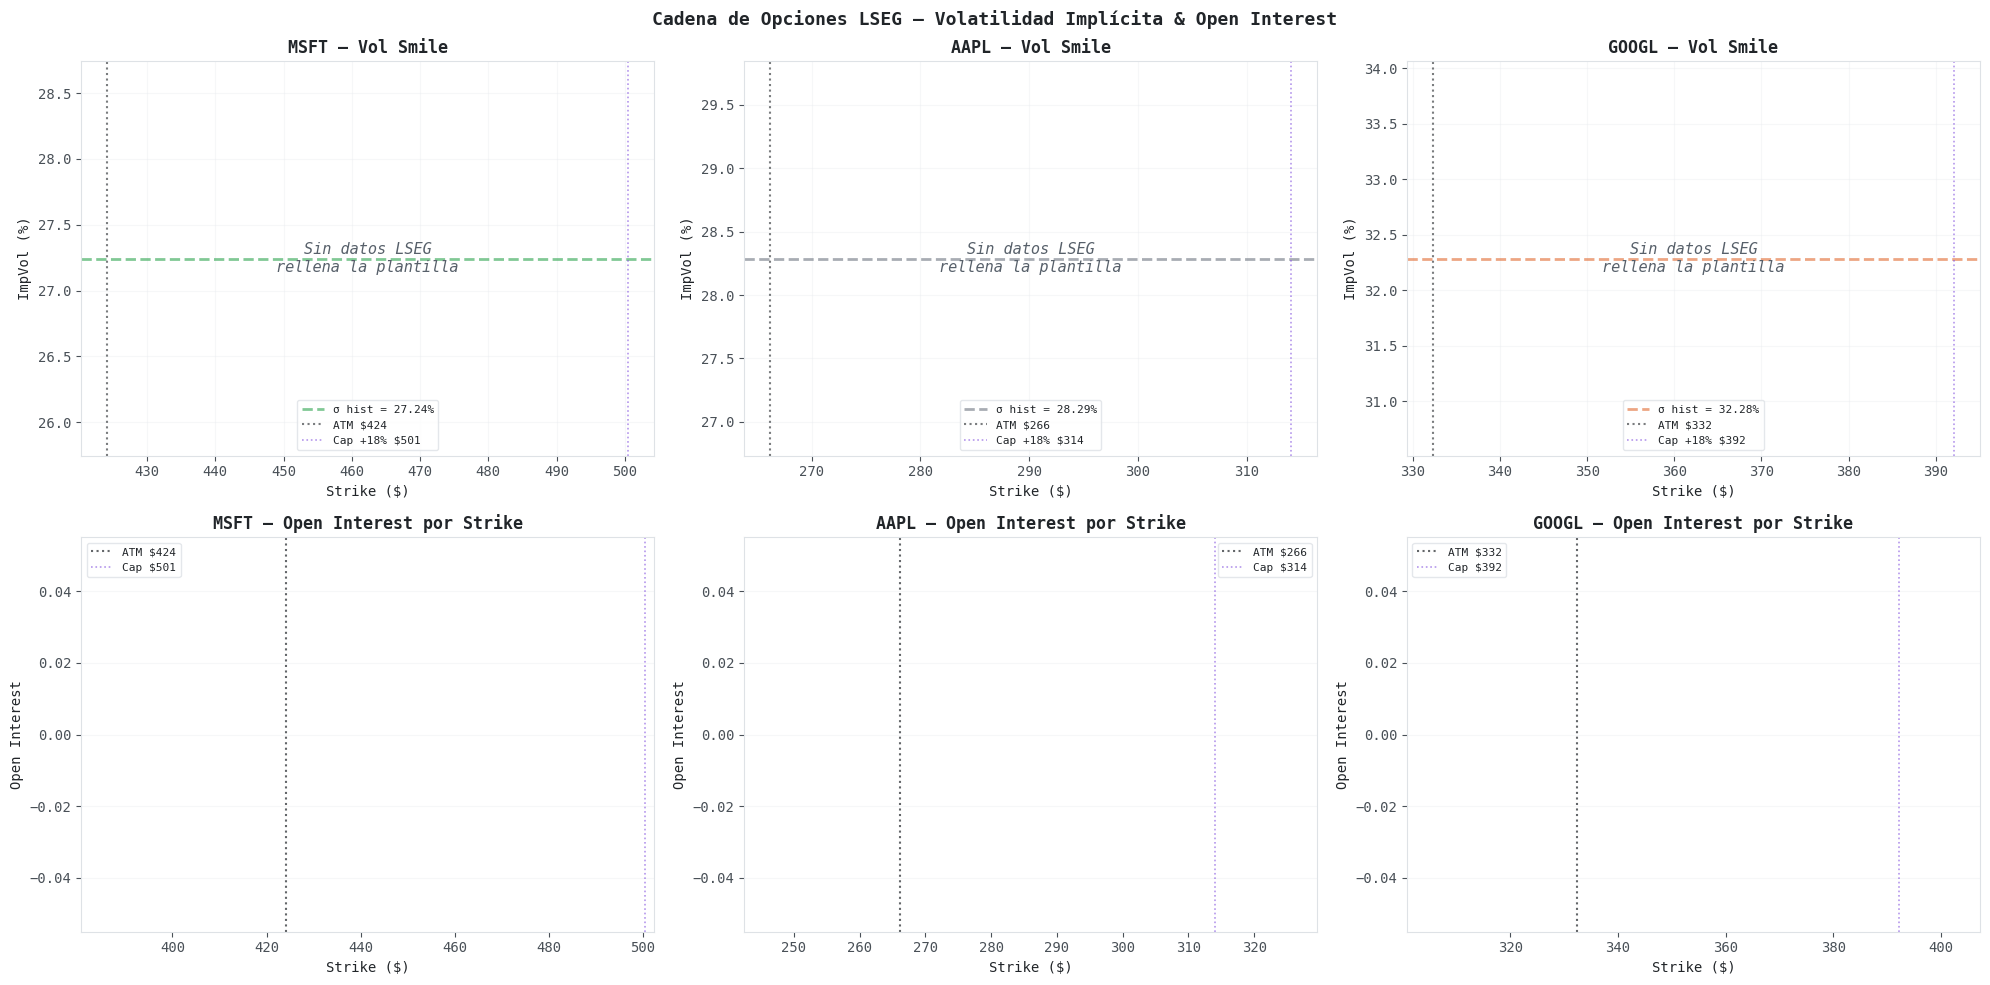

In [20]:
# ── Smile de Volatilidad y Posicionamiento (OI) ────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Cadena de Opciones LSEG — Volatilidad Implícita & Open Interest',
             fontsize=13, fontweight='bold')

for i, ticker in enumerate(TICKERS):
    df_opts = options_lseg[ticker]
    S       = S0[ticker]
    strikes = df_opts['Strike'].values
    ivols   = df_opts['ImpVol_Mid'].values
    ois     = df_opts['OI'].values
    deltas  = df_opts['Delta_Mid'].values
    color   = COLORS[ticker]

    # ── Smile de volatilidad ────────────────────────────────
    ax = axes[0, i]
    ax.axhline(VOL[ticker]*100, color=color, ls='--', lw=2, alpha=0.6,
               label=f'σ hist = {VOL[ticker]*100:.2f}%')
    mask = ivols > 0
    if mask.any():
        size = np.maximum(ois[mask] / max(ois[mask].max(), 1) * 250, 40)
        ax.scatter(strikes[mask], ivols[mask]*100, s=size,
                   color=color, zorder=5, alpha=0.85,
                   label='ImpVol LSEG (tamaño = OI)')
        ax.plot(strikes[mask], ivols[mask]*100, color=color, lw=1.5, alpha=0.4)
    else:
        # Sin datos: mostrar línea de vol histórica como referencia
        ax.text(0.5, 0.5, 'Sin datos LSEG\nrellena la plantilla',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=11, color='#57606a', style='italic')

    ax.axvline(S, color='#212529', ls=':', lw=1.5, alpha=0.6, label=f'ATM ${S:.0f}')
    ax.axvline(S * 1.18, color=COLORS['highlight'], ls=':', lw=1.2, alpha=0.6,
               label=f'Cap +18% ${S*1.18:.0f}')
    ax.set_title(f'{ticker} — Vol Smile', fontweight='bold')
    ax.set_xlabel('Strike ($)'); ax.set_ylabel('ImpVol (%)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # ── Open Interest por strike ────────────────────────────
    ax2 = axes[1, i]
    oi_vals = np.where(ois > 0, ois, 0)
    bars = ax2.bar(strikes, oi_vals, width=(strikes.max()-strikes.min())/len(strikes)*0.6,
                   color=color, alpha=0.75, edgecolor='white')
    ax2.axvline(S, color='#212529', ls=':', lw=1.5, alpha=0.7, label=f'ATM ${S:.0f}')
    ax2.axvline(S * 1.18, color=COLORS['highlight'], ls=':', lw=1.2, alpha=0.6,
                label=f'Cap ${S*1.18:.0f}')
    for bar, val in zip(bars, oi_vals):
        if val > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{int(val):,}', ha='center', va='bottom', fontsize=8, color='#212529')
    ax2.set_title(f'{ticker} — Open Interest por Strike', fontweight='bold')
    ax2.set_xlabel('Strike ($)'); ax2.set_ylabel('Open Interest')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


In [21]:
# ── Re-pricing del Spread con Vol Implícita de Mercado ─────
# Si hay datos reales de ImpVol, calcula cuánto cambia el presupuesto
# y la tasa de participación al usar vols de mercado en lugar de hist.

print('═'*68)
print('  RE-PRICING BULL CALL SPREAD CON VOLS IMPLÍCITAS LSEG')
print('═'*68)

for ticker in TICKERS:
    df_opts = options_lseg[ticker]
    S       = S0[ticker]
    
    # Buscar vol implícita ATM (strike más cercano a S)
    ivols = df_opts['ImpVol_Mid'].values
    strikes = df_opts['Strike'].values
    
    if ivols.max() > 0:
        atm_idx   = np.argmin(np.abs(strikes - S))
        iv_atm    = ivols[atm_idx]
        
        # Strike OTM del spread en términos individuales: K_atm*1.18
        K_atm_ind = S
        K_otm_ind = S * 1.18
        
        # Buscar vol OTM en los datos (más cercano a K_otm)
        otm_idx = np.argmin(np.abs(strikes - K_otm_ind))
        iv_otm  = ivols[otm_idx] if ivols[otm_idx] > 0 else iv_atm
        
        # Pricing con vols de mercado
        c_l_mkt = bs_call(S, K_atm_ind, T_6M, RATE_6M, iv_atm, DIV[ticker])
        c_s_mkt = bs_call(S, K_otm_ind, T_6M, RATE_6M, iv_otm, DIV[ticker])
        sc_mkt  = max(c_l_mkt - c_s_mkt, 1e-8)
        
        # Presupuesto individual por activo (basket weight × budget total)
        budget_ticker = budget_C * weights_C[ticker]
        part_mkt      = budget_ticker / (S * sc_mkt)
        
        print(f'\n  {ticker}:')
        print(f'    Vol hist (σ):       {VOL[ticker]*100:.2f}%')
        print(f'    ImpVol ATM (LSEG):  {iv_atm*100:.2f}%  (K≈${strikes[atm_idx]:.0f})')
        print(f'    ImpVol OTM (LSEG):  {iv_otm*100:.2f}%  (K≈${strikes[otm_idx]:.0f})')
        print(f'    Long Call ATM  hist=${bs_call(S,K_atm_ind,T_6M,RATE_6M,VOL[ticker],DIV[ticker]):.4f}  '
              f'mkt=${c_l_mkt:.4f}')
        print(f'    Short Call OTM hist=${bs_call(S,K_otm_ind,T_6M,RATE_6M,VOL[ticker],DIV[ticker]):.4f}  '
              f'mkt=${c_s_mkt:.4f}')
    else:
        print(f'\n  {ticker}: sin datos LSEG — rellena ImpVol_Mid en la plantilla')

print('\n' + '═'*68)
print('  Nota: el repricing individual sirve como referencia para negociar')
print('  el spread con dealers. El basket consolida vols por correlación.')
print('═'*68)


════════════════════════════════════════════════════════════════════
  RE-PRICING BULL CALL SPREAD CON VOLS IMPLÍCITAS LSEG
════════════════════════════════════════════════════════════════════

  MSFT: sin datos LSEG — rellena ImpVol_Mid en la plantilla

  AAPL: sin datos LSEG — rellena ImpVol_Mid en la plantilla

  GOOGL: sin datos LSEG — rellena ImpVol_Mid en la plantilla

════════════════════════════════════════════════════════════════════
  Nota: el repricing individual sirve como referencia para negociar
  el spread con dealers. El basket consolida vols por correlación.
════════════════════════════════════════════════════════════════════
